In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 12 phyto (0.5–200 µm), 12 zoo (5–2000 µm)


In [2]:
# ── Cell 2 — builder, regime forcings, helpers, BUILD-ONLY smoke test ─────────
import numpy as np
import run_baseline_diagnostic as rbd
from cariaco_baseline_comps import (
    Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum, StockNutrientSupply,
    MonodGrowth_NP, PhytoLinearLoss_recycled, ZooLinearLoss_recycled,
    MatchedGrazing_TypeII, MatchedGrazing_TypeIII, PhytoSinking_export,
)
from np_comps import ZooQuadraticLoss_recycled   # 100%-to-N quadratic closure

# ---- fixed structural / parameter choices (Taniguchi Table 1 + MS3 settled) ----
ESD_MIN, ESD_MAX = 0.2, 200.0          # 0.2 µm floor from now on (data-bounded)
ZOO_RATIO        = cbs.ZOO_PHYTO_RATIO # 10
GAMMA            = cbs.GAMMA_VAL       # 0.25
LAMBDA           = cbs.LAMBDA_VAL      # 0.0015 d-1 phyto
DELTA_LIT        = cbs.DELTA_VAL       # 0.025  d-1 zoo (literature linear)
W_SINK           = cbs.W_SINK          # 5 m/d
M_Z              = 0.1                 # quadratic closure coeff [(mmolN/m3)^-1 d-1]
N_REF            = 40                  # anchor for K_sZ resolution scaling

GRAZ = {'II': MatchedGrazing_TypeII, 'III': MatchedGrazing_TypeIII}
CLOS = {'lin': ZooLinearLoss_recycled, 'quad': ZooQuadraticLoss_recycled}

def build_setup(N, response, closure, ksz_scaling='fixed',
                fn=cbs.FN_DEFAULT, de=cbs.DE_DEFAULT):
    """Build (model, setup, meta) for one construct at resolution N."""
    p = np.logspace(np.log10(ESD_MIN), np.log10(ESD_MAX), N)
    z = ZOO_RATIO * p
    mu   = 1.36  * p ** (-0.16)        # Taniguchi Eq.7
    ks   = 0.33  * p ** ( 0.48)        # Taniguchi Eq.8
    Imax = 33.96 * z ** (-0.66)        # Taniguchi Eq.9
    KsZ  = 17.92 * z ** (-0.64)        # Taniguchi Eq.10
    ksz_factor = (N_REF / N) if ksz_scaling == 'per_class' else 1.0
    KsZ = KsZ * ksz_factor             # ∝1/N to track per-class prey density
    p_init, z_init = np.full(N, 1e-3), np.full(N, 1e-3)

    model = xso.create({
        'Nutrient': Nutrient, 'Phytoplankton': PhytoSizeSpectrum,
        'Zooplankton': ZooSizeSpectrum, 'Inflow': StockNutrientSupply,
        'Growth': MonodGrowth_NP, 'Grazing': GRAZ[response],
        'PhytoLoss': PhytoLinearLoss_recycled, 'ZooLoss': CLOS[closure],
        'PhytoSinking': PhytoSinking_export,
    })
    zooloss = ({'population': 'Z', 'nutrient': 'N', 'rate': M_Z} if closure == 'quad'
               else {'population': 'Z', 'nutrient': 'N', 'rate': np.full(N, DELTA_LIT)})
    iv = {
        'Nutrient':      {'value_label': 'N', 'value_init': 1.0},
        'Phytoplankton': {'biomass_label': 'P', 'biomass_init': p_init,
                          'phyto_esd_index': p.tolist(), 'phyto_esd_label': 'phyto_esd'},
        'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': z_init,
                          'zoo_esd_index': z.tolist(), 'zoo_esd_label': 'zoo_esd'},
        'Inflow':        {'var': 'N', 'FN': fn, 'de': de, 'de_label': 'de'},
        'Growth':        {'resource': 'N', 'consumer': 'P', 'mu_max': mu, 'halfsat': ks},
        'Grazing':       {'phyto': 'P', 'zoo': 'Z', 'nutrient': 'N',
                          'Imax': Imax, 'KsZ': KsZ, 'gamma': GAMMA},
        'PhytoLoss':     {'population': 'P', 'nutrient': 'N', 'rate': np.full(N, LAMBDA)},
        'ZooLoss':       zooloss,
        'PhytoSinking':  {'population': 'P', 'w_sink': W_SINK, 'de': 'de'},
    }
    setup = xso.setup(solver='solve_ivp', model=model, time=cbs.ivp_time_array,
                      input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS)
    meta = dict(N=N, response=response, closure=closure, phyto_esd=p, zoo_esd=z,
                KsZ=KsZ, ksz_factor=ksz_factor)
    return model, setup, meta

def native_mcs(P_tail, esd, floor=1e-6):
    tot = P_tail.sum()
    if tot <= floor: return np.nan
    return 10 ** np.sum((P_tail / tot) * np.log10(esd))

def summarize_run(out, meta, tail=1000):
    st = rbd.extract_state(out)
    P_tail = st['P'][:, -tail:].mean(axis=1)
    Z_tail = st['Z'][:, -tail:].mean(axis=1)
    sumP_t = st['P'].sum(axis=0)[-tail:]
    cv_sumP = float(sumP_t.std() / abs(sumP_t.mean())) if sumP_t.mean() != 0 else np.nan
    stab = rbd.stability_summary(st, tail_len=tail, verbose=False)
    cen = rbd.compute_metrics(st, meta['phyto_esd'], meta['zoo_esd'], tail_len=tail)
    active = P_tail > 1e-6
    return dict(
        sumP=float(P_tail.sum()), sumZ=float(Z_tail.sum()),
        cv_sumP=cv_sumP, max_cv_P=stab['max_cv_P'], max_cv_Z=stab['max_cv_Z'],
        mcs_native=native_mcs(P_tail, meta['phyto_esd']),
        mcs_binned=10 ** cen['centroid'], centroid=cen['centroid'],
        n_active_P=int(active.sum()),
        medP_active=float(np.median(P_tail[active])) if active.any() else np.nan,
        medKsZ=float(np.median(meta['KsZ'])),
        de_used=float(out['Inflow__de'].values),
    )

# ---- regime forcings (median over HPLC months; index 4 = forcing dict) --------
FORC = {r: co.load_cariaco_targets(regime=r, months='hplc', agg='median')[4]
        for r in ('upwelling', 'relaxed')}
print('Regime forcings (Inflow__FN, Inflow__de):')
for r, f in FORC.items():
    print(f'  {r:10s}  F_N={f["Inflow__FN"]:.3f}  d_e={f["Inflow__de"]:.2f}')

# ---- BUILD-ONLY smoke test: all 4 constructs at N=12, no heavy run ------------
print('\nBuild smoke test (N=12, fixed vs per_class K_sZ):')
for clo in ('lin', 'quad'):
    for resp in ('II', 'III'):
        for scal in ('fixed', 'per_class'):
            _, _, m = build_setup(12, resp, clo, ksz_scaling=scal)
            rate_kind = 'scalar m_Z=0.1' if clo == 'quad' else f'array Δ={DELTA_LIT}'
            print(f'  Type {resp:3s} {clo:4s} | KsZ[{scal:9s}] '
                  f'med={np.median(m["KsZ"]):.3f} (×{m["ksz_factor"]:.2f}) | '
                  f'closure rate = {rate_kind} | grid {m["phyto_esd"][0]:.2g}-'
                  f'{m["phyto_esd"][-1]:.0f}µm')
print('\nIf forcings and the 4 constructs print as expected, run Cell 3.')

Regime forcings (Inflow__FN, Inflow__de):
  upwelling   F_N=2.579  d_e=42.79
  relaxed     F_N=1.450  d_e=52.66

Build smoke test (N=12, fixed vs per_class K_sZ):
  Type II  lin  | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type II  lin  | KsZ[per_class] med=4.288 (×3.33) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type III lin  | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type III lin  | KsZ[per_class] med=4.288 (×3.33) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type II  quad | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm
  Type II  quad | KsZ[per_class] med=4.288 (×3.33) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm
  Type III quad | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm
  Type III quad | KsZ[per_class] med=4.288 (×3.33) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm

If forcings and the 4 constructs print a

In [3]:
# ── Cell 3 — 2×2 × resolution × regime sweep: CV(ΣP), native mcs, contrast ────
# Run once with KSZ_SCALING='fixed' (raw artifact), then 'per_class' (scaled).
KSZ_SCALING = 'fixed'          # 'fixed' | 'per_class'
LINEAR_MODE = 'matched'        # 'matched' (Δ=m_Z·ΣZ_quad) | 'literature' (0.025)
N_LIST      = [12, 24, 40, 80] # trim to [12,24,40] for a fast first pass
TAIL        = 1000

print(f'config: KSZ_SCALING={KSZ_SCALING}  LINEAR_MODE={LINEAR_MODE}  '
      f'M_Z={M_Z}  N_REF={N_REF}  tail={TAIL}d  IVP_END={cbs.IVP_TIME_END:.0f}d')

# build all 16 constructs (forcing overridden per run)
builds = {(N, resp, clo): build_setup(N, resp, clo, ksz_scaling=KSZ_SCALING)
          for N in N_LIST for resp in ('II', 'III') for clo in ('lin', 'quad')}

res = {}   # (regime, N, resp, clo) -> summary dict
for rname, f in FORC.items():
    fn, de = f['Inflow__FN'], f['Inflow__de']
    ov_forc = {'Inflow': {'FN': fn, 'de': de}}
    print(f'\n===== {rname.upper()}  (F_N={fn:.3f}, d_e={de:.2f}) =====')
    for N in N_LIST:
        # quadratic first (gives ΣZ to set the matched linear Δ)
        sigZ = {}
        for resp in ('II', 'III'):
            m, s, meta = builds[(N, resp, 'quad')]
            out = rbd.run_setup(m, s, ov_forc)
            r = summarize_run(out, meta, tail=TAIL); r['delta_lin'] = np.nan
            res[(rname, N, resp, 'quad')] = r; sigZ[resp] = r['sumZ']
        # linear (matched magnitude from the same-response quad ΣZ)
        for resp in ('II', 'III'):
            m, s, meta = builds[(N, resp, 'lin')]
            ov = dict(ov_forc)
            dl = (M_Z * sigZ[resp]) if LINEAR_MODE == 'matched' else DELTA_LIT
            ov['ZooLoss'] = {'rate': np.full(N, dl)}
            out = rbd.run_setup(m, s, ov)
            r = summarize_run(out, meta, tail=TAIL); r['delta_lin'] = dl
            res[(rname, N, resp, 'lin')] = r
        # per-N line
        for resp in ('II', 'III'):
            for clo in ('quad', 'lin'):
                r = res[(rname, N, resp, clo)]
                print(f'  N={N:3d} TypeptII{resp:>0s}'.replace('ptII', '') +
                      f'{resp:3s} {clo:4s} | CV(ΣP)={r["cv_sumP"]:.3f} '
                      f'maxCV_P={r["max_cv_P"]:.3f} | mcs_nat={r["mcs_native"]:.2f} '
                      f'mcs_bin={r["mcs_binned"]:.2f}µm | ΣP={r["sumP"]:.3f} '
                      f'ΣZ={r["sumZ"]:.3f} | act_P={r["n_active_P"]:2d}/{N} | '
                      f'medP/KsZ={r["medP_active"]/r["medKsZ"]:.2g}'
                      + (f' Δlin={r["delta_lin"]:.4f}' if clo == 'lin' else ''))

# ---- summary tables: native mcs and CV per construct across N -----------------
def table(metric, label, fmt='{:7.2f}'):
    print(f'\n{label}  (rows=construct, cols=N)')
    print('  construct      ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
    for resp in ('II', 'III'):
        for clo in ('lin', 'quad'):
            for rname in ('upwelling', 'relaxed'):
                vals = ''.join(fmt.format(res[(rname, N, resp, clo)][metric])
                               for N in N_LIST)
                print(f'  T{resp:3s} {clo:4s} {rname:9s}' + ''.join(
                    f'{v:>9s}' for v in [fmt.format(res[(rname,N,resp,clo)][metric])
                                         for N in N_LIST]))

table('mcs_native', 'NATIVE MEAN CELL SIZE [µm]')
table('cv_sumP',    'CV(ΣP)', fmt='{:7.3f}')

# ---- THE robustness readout: upwelling↔relaxed contrast vs N -----------------
print('\nREGIME CONTRAST in native mcs  (upwelling − relaxed, and ratio)  vs N')
print('  construct ' + ''.join(f'{("N="+str(N)):>16s}' for N in N_LIST))
for resp in ('II', 'III'):
    for clo in ('lin', 'quad'):
        cells = []
        for N in N_LIST:
            u = res[('upwelling', N, resp, clo)]['mcs_native']
            r = res[('relaxed',   N, resp, clo)]['mcs_native']
            cells.append(f'{u-r:+6.2f}/{u/r:4.2f}x')
        print(f'  T{resp:3s} {clo:4s} ' + ''.join(f'{c:>16s}' for c in cells))
print('\nResolution-robust + stable construct = flat contrast across N AND CV(ΣP)→0.')

config: KSZ_SCALING=fixed  LINEAR_MODE=matched  M_Z=0.1  N_REF=40  tail=1000d  IVP_END=5000d

===== UPWELLING  (F_N=2.579, d_e=42.79) =====


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 12 TypeIIII  quad | CV(ΣP)=0.023 maxCV_P=0.385 | mcs_nat=0.72 mcs_bin=0.94µm | ΣP=0.516 ΣZ=0.458 | act_P= 5/12 | medP/KsZ=0.08
  N= 12 TypeIIII  lin  | CV(ΣP)=0.059 maxCV_P=0.717 | mcs_nat=0.73 mcs_bin=0.94µm | ΣP=0.517 ΣZ=0.422 | act_P= 5/12 | medP/KsZ=0.081 Δlin=0.0458
  N= 12 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.108 | act_P= 1/12 | medP/KsZ=0.4
  N= 12 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.001 | act_P= 1/12 | medP/KsZ=0.4 Δlin=0.0108


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 24 TypeIIII  quad | CV(ΣP)=0.018 maxCV_P=0.555 | mcs_nat=0.47 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.357 | act_P= 7/24 | medP/KsZ=0.062
  N= 24 TypeIIII  lin  | CV(ΣP)=0.066 maxCV_P=1.510 | mcs_nat=0.46 mcs_bin=0.63µm | ΣP=0.515 ΣZ=0.366 | act_P= 7/24 | medP/KsZ=0.062 Δlin=0.0357
  N= 24 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.108 | act_P= 1/24 | medP/KsZ=0.41
  N= 24 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.001 | act_P= 1/24 | medP/KsZ=0.41 Δlin=0.0108


...

/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 40 TypeIIII  quad | CV(ΣP)=0.008 maxCV_P=0.418 | mcs_nat=0.34 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.190 | act_P= 7/40 | medP/KsZ=0.033
  N= 40 TypeIIII  lin  | CV(ΣP)=0.038 maxCV_P=1.572 | mcs_nat=0.35 mcs_bin=0.63µm | ΣP=0.291 ΣZ=0.131 | act_P= 7/40 | medP/KsZ=0.033 Δlin=0.0190
  N= 40 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.034 | act_P= 1/40 | medP/KsZ=0.23
  N= 40 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.001 | act_P= 1/40 | medP/KsZ=0.23 Δlin=0.0034


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 80 TypeIIII  quad | CV(ΣP)=0.009 maxCV_P=0.853 | mcs_nat=0.28 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.148 | act_P=10/80 | medP/KsZ=0.025
  N= 80 TypeIIII  lin  | CV(ΣP)=0.021 maxCV_P=1.595 | mcs_nat=0.28 mcs_bin=0.63µm | ΣP=0.289 ΣZ=0.098 | act_P= 9/80 | medP/KsZ=0.026 Δlin=0.0148
  N= 80 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.034 | act_P= 1/80 | medP/KsZ=0.23
  N= 80 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.000 | act_P= 1/80 | medP/KsZ=0.23 Δlin=0.0034

NATIVE MEAN CELL SIZE [µm]  (rows=construct, cols=N)
  construct           N=12     N=24     N=40     N=80
  TII  lin  upwelling     0.73     0.46     0.37     0.31
  TII  lin  relaxed       0.52     0.42     0.35     0.28
  TII  quad upwelling     0.72     0.47     0.37     0.31
  TII  quad relaxed       0.52     0.43     0.34     0.28
  TIII lin  upwelling     0.20     0.20     0.20     0.21
  TIII lin  relaxed       0.20     0.20     0.

/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


In [4]:
# ── Cell 4 — run BOTH K_sZ scalings into one dict (also stores tail spectra) ──
import numpy as np

def summarize_run(out, meta, tail=1000):   # redefining: adds P_tail/esd, mutes 0/0
    st = rbd.extract_state(out)
    P_tail = st['P'][:, -tail:].mean(axis=1)
    Z_tail = st['Z'][:, -tail:].mean(axis=1)
    sumP_t = st['P'].sum(axis=0)[-tail:]
    cv_sumP = float(sumP_t.std() / abs(sumP_t.mean())) if sumP_t.mean() != 0 else np.nan
    with np.errstate(invalid='ignore', divide='ignore'):
        stab = rbd.stability_summary(st, tail_len=tail, verbose=False)
    cen = rbd.compute_metrics(st, meta['phyto_esd'], meta['zoo_esd'], tail_len=tail)
    active = P_tail > 1e-6
    return dict(
        sumP=float(P_tail.sum()), sumZ=float(Z_tail.sum()),
        cv_sumP=cv_sumP, max_cv_P=stab['max_cv_P'], max_cv_Z=stab['max_cv_Z'],
        mcs_native=native_mcs(P_tail, meta['phyto_esd']),
        mcs_binned=10 ** cen['centroid'], centroid=cen['centroid'],
        n_active_P=int(active.sum()),
        medP_active=float(np.median(P_tail[active])) if active.any() else np.nan,
        medKsZ=float(np.median(meta['KsZ'])),
        P_tail=P_tail, esd=meta['phyto_esd'])

def run_sweep(ksz_scaling, N_LIST, LINEAR_MODE='matched', TAIL=1000, verbose=True):
    builds = {(N, resp, clo): build_setup(N, resp, clo, ksz_scaling=ksz_scaling)
              for N in N_LIST for resp in ('II', 'III') for clo in ('lin', 'quad')}
    res = {}
    for rname, f in FORC.items():
        ov_forc = {'Inflow': {'FN': f['Inflow__FN'], 'de': f['Inflow__de']}}
        for N in N_LIST:
            sigZ = {}
            for resp in ('II', 'III'):
                m, s, meta = builds[(N, resp, 'quad')]
                r = summarize_run(rbd.run_setup(m, s, ov_forc), meta, tail=TAIL)
                r['delta_lin'] = np.nan
                res[(rname, N, resp, 'quad')] = r; sigZ[resp] = r['sumZ']
            for resp in ('II', 'III'):
                m, s, meta = builds[(N, resp, 'lin')]
                ov = dict(ov_forc)
                dl = (M_Z * sigZ[resp]) if LINEAR_MODE == 'matched' else DELTA_LIT
                ov['ZooLoss'] = {'rate': np.full(N, dl)}
                r = summarize_run(rbd.run_setup(m, s, ov), meta, tail=TAIL)
                r['delta_lin'] = dl
                res[(rname, N, resp, 'lin')] = r
            if verbose:
                print(f'  [{ksz_scaling:9s}] {rname:10s} N={N:3d} done')
    return res

N_LIST = [12, 24, 40, 80]
SWEEP = {'fixed':     run_sweep('fixed', N_LIST),
         'per_class': run_sweep('per_class', N_LIST)}
print('SWEEP ready:', list(SWEEP))

# compact comparison: native mcs (upwelling), fixed vs per_class
print('\nNative mcs [µm] — Type II quad (upwelling) — fixed vs per_class:')
print('  N    ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
for scal in ('fixed', 'per_class'):
    vals = [SWEEP[scal][('upwelling', N, 'II', 'quad')]['mcs_native'] for N in N_LIST]
    print(f'  {scal:9s}' + ''.join(f'{v:9.2f}' for v in vals))
print('  active_P (per_class):',
      [SWEEP['per_class'][('upwelling', N, 'II', 'quad')]['n_active_P'] for N in N_LIST])
print('  medP/KsZ (per_class):',
      [round(SWEEP['per_class'][('upwelling', N, 'II', 'quad')]['medP_active'] /
             SWEEP['per_class'][('upwelling', N, 'II', 'quad')]['medKsZ'], 3) for N in N_LIST])

  [fixed    ] upwelling  N= 12 done
  [fixed    ] upwelling  N= 24 done
  [fixed    ] upwelling  N= 40 done
  [fixed    ] upwelling  N= 80 done
  [fixed    ] relaxed    N= 12 done
  [fixed    ] relaxed    N= 24 done
  [fixed    ] relaxed    N= 40 done
  [fixed    ] relaxed    N= 80 done
  [per_class] upwelling  N= 12 done
  [per_class] upwelling  N= 24 done
  [per_class] upwelling  N= 40 done
  [per_class] upwelling  N= 80 done
  [per_class] relaxed    N= 12 done
  [per_class] relaxed    N= 24 done
  [per_class] relaxed    N= 40 done
  [per_class] relaxed    N= 80 done
SWEEP ready: ['fixed', 'per_class']

Native mcs [µm] — Type II quad (upwelling) — fixed vs per_class:
  N         N=12     N=24     N=40     N=80
  fixed         0.72     0.47     0.37     0.31
  per_class     0.29     0.37     0.37     0.39
  active_P (per_class): [3, 5, 8, 16]
  medP/KsZ (per_class): [0.055, 0.049, 0.051, 0.051]


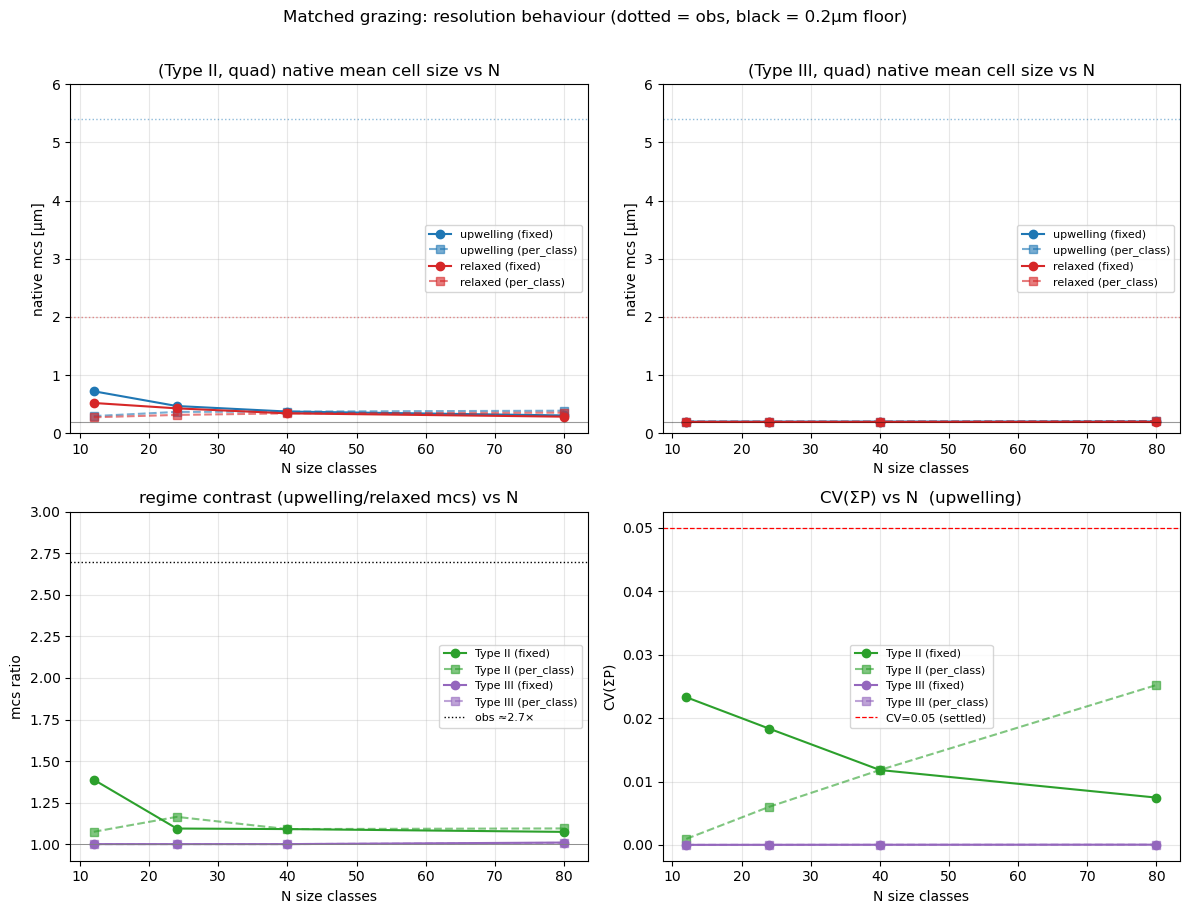

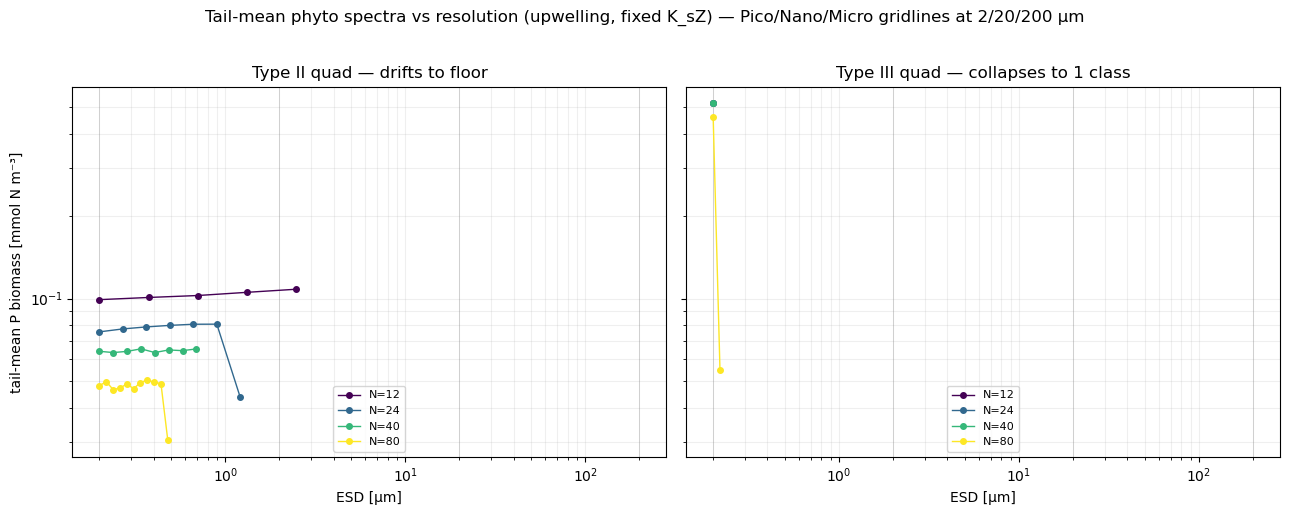

In [5]:
# ── Cell 5 — visualize the matched 2×2 × resolution scan ─────────────────────
import matplotlib.pyplot as plt
import numpy as np

UP_OBS, REL_OBS, FLOOR = 5.4, 2.0, 0.2          # obs medians (µm), grid floor
ser = lambda res, rn, rp, cl, mt: [res[(rn, N, rp, cl)][mt] for N in N_LIST]
ratio = lambda res, rp, cl: [res[('upwelling', N, rp, cl)]['mcs_native'] /
                             res[('relaxed', N, rp, cl)]['mcs_native'] for N in N_LIST]

# ---- Figure 1: convergence, contrast, stability (quad closure; lin ~identical) ----
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
for axx, resp in zip((ax[0, 0], ax[0, 1]), ('II', 'III')):
    for rn, col in (('upwelling', 'C0'), ('relaxed', 'C3')):
        axx.plot(N_LIST, ser(SWEEP['fixed'], rn, resp, 'quad', 'mcs_native'),
                 'o-', color=col, label=f'{rn} (fixed)')
        axx.plot(N_LIST, ser(SWEEP['per_class'], rn, resp, 'quad', 'mcs_native'),
                 's--', color=col, alpha=0.6, label=f'{rn} (per_class)')
    axx.axhline(UP_OBS, color='C0', ls=':', lw=1, alpha=0.5)
    axx.axhline(REL_OBS, color='C3', ls=':', lw=1, alpha=0.5)
    axx.axhline(FLOOR, color='k', ls='-', lw=0.8, alpha=0.4)
    axx.set(title=f'(Type {resp}, quad) native mean cell size vs N',
            xlabel='N size classes', ylabel='native mcs [µm]', ylim=(0, 6))
    axx.legend(fontsize=8); axx.grid(alpha=0.3)

for resp, c in (('II', 'C2'), ('III', 'C4')):
    ax[1, 0].plot(N_LIST, ratio(SWEEP['fixed'], resp, 'quad'), 'o-', color=c,
                  label=f'Type {resp} (fixed)')
    ax[1, 0].plot(N_LIST, ratio(SWEEP['per_class'], resp, 'quad'), 's--', color=c,
                  alpha=0.6, label=f'Type {resp} (per_class)')
ax[1, 0].axhline(UP_OBS / REL_OBS, color='k', ls=':', lw=1, label=f'obs ≈{UP_OBS/REL_OBS:.1f}×')
ax[1, 0].axhline(1.0, color='grey', lw=0.6)
ax[1, 0].set(title='regime contrast (upwelling/relaxed mcs) vs N',
             xlabel='N size classes', ylabel='mcs ratio', ylim=(0.9, 3.0))
ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=0.3)

for resp, c in (('II', 'C2'), ('III', 'C4')):
    ax[1, 1].plot(N_LIST, ser(SWEEP['fixed'], 'upwelling', resp, 'quad', 'cv_sumP'),
                  'o-', color=c, label=f'Type {resp} (fixed)')
    ax[1, 1].plot(N_LIST, ser(SWEEP['per_class'], 'upwelling', resp, 'quad', 'cv_sumP'),
                  's--', color=c, alpha=0.6, label=f'Type {resp} (per_class)')
ax[1, 1].axhline(0.05, color='red', ls='--', lw=0.9, label='CV=0.05 (settled)')
ax[1, 1].set(title='CV(ΣP) vs N  (upwelling)',
             xlabel='N size classes', ylabel='CV(ΣP)')
ax[1, 1].legend(fontsize=8); ax[1, 1].grid(alpha=0.3)
plt.suptitle('Matched grazing: resolution behaviour (dotted = obs, black = 0.2µm floor)',
             y=1.01); plt.tight_layout(); plt.show()

# ---- Figure 2: tail-mean spectra across N (the resolution artifact, upwelling) ----
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.viridis(np.linspace(0, 1, len(N_LIST)))
for axx, resp, ttl in zip(ax, ('II', 'III'),
                          ('Type II quad — drifts to floor', 'Type III quad — collapses to 1 class')):
    for axv in (0.2, 2.0, 20.0, 200.0):
        axx.axvline(axv, color='grey', lw=0.5, alpha=0.4)
    for k, N in enumerate(N_LIST):
        d = SWEEP['fixed'][('upwelling', N, resp, 'quad')]
        msk = d['P_tail'] > 1e-10
        axx.loglog(d['esd'][msk], d['P_tail'][msk], 'o-', color=cmap[k],
                   ms=4, lw=1, label=f'N={N}')
    axx.set(title=ttl, xlabel='ESD [µm]')
    axx.legend(fontsize=8); axx.grid(alpha=0.2, which='both')
ax[0].set_ylabel('tail-mean P biomass [mmol N m⁻³]')
plt.suptitle('Tail-mean phyto spectra vs resolution (upwelling, fixed K_sZ) — '
             'Pico/Nano/Micro gridlines at 2/20/200 µm', y=1.02)
plt.tight_layout(); plt.show()

In [6]:
# ── Cell 6 — distributed-grazing builder (np_comps group-flux) + smoke ────────
import numpy as np
from np_comps import GrazingMatrix_TypeII, GrazingMatrix_TypeIII, GrazingRouter

THETA_OPT, SIGMA_LOG = 10.0, 0.25
IMAX_DIST, KSZ_DIST  = 3.0, 3.0          # uniform (Banas / Correction.md settled)

def compute_phiPZ(p, z, mode, theta_opt=THETA_OPT, sigma_log=SIGMA_LOG):
    n_P, n_Z = len(p), len(z)
    prey = np.concatenate([p, z])
    log_ratio = np.log10(z[None, :] / prey[:, None])
    kernel = np.exp(-((log_ratio - np.log10(theta_opt)) ** 2) / (2 * sigma_log ** 2))
    phi = np.zeros((n_P + n_Z, n_Z))
    if mode == 'matched':
        for j in range(n_Z): phi[j, j] = 1.0
    elif mode == 'herb':
        phi[:n_P, :] = kernel[:n_P, :]
    elif mode == 'omni':
        phi[:] = kernel
        for j in range(n_Z): phi[n_P + j, j] = 0.0
    else:
        raise ValueError(mode)
    return phi

GRAZ_DIST = {'II': GrazingMatrix_TypeII, 'III': GrazingMatrix_TypeIII}

def build_setup_dist(N, response, mode, fn=cbs.FN_DEFAULT, de=cbs.DE_DEFAULT):
    p = np.logspace(np.log10(ESD_MIN), np.log10(ESD_MAX), N)
    z = ZOO_RATIO * p
    mu = 1.36 * p ** (-0.16); ks = 0.33 * p ** (0.48)
    phi = compute_phiPZ(p, z, mode)
    model = xso.create({
        'Nutrient': Nutrient, 'Phytoplankton': PhytoSizeSpectrum,
        'Zooplankton': ZooSizeSpectrum, 'Inflow': StockNutrientSupply,
        'Growth': MonodGrowth_NP, 'Grazing': GRAZ_DIST[response],
        'GrazingRouter': GrazingRouter, 'PhytoLoss': PhytoLinearLoss_recycled,
        'ZooLoss': ZooQuadraticLoss_recycled, 'PhytoSinking': PhytoSinking_export,
    })
    iv = {
        'Nutrient':      {'value_label': 'N', 'value_init': 1.0},
        'Phytoplankton': {'biomass_label': 'P', 'biomass_init': np.full(N, 1e-3),
                          'phyto_esd_index': p.tolist(), 'phyto_esd_label': 'phyto_esd'},
        'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': np.full(N, 1e-3),
                          'zoo_esd_index': z.tolist(), 'zoo_esd_label': 'zoo_esd'},
        'Inflow':        {'var': 'N', 'FN': fn, 'de': de, 'de_label': 'de'},
        'Growth':        {'resource': 'N', 'consumer': 'P', 'mu_max': mu, 'halfsat': ks},
        'Grazing':       {'resource': 'P', 'consumer': 'Z', 'phiPZ': phi,
                          'Imax': np.full(N, IMAX_DIST), 'KsZ': KSZ_DIST},
        'GrazingRouter': {'grazed_phyto': 'P', 'grazed_zoo': 'Z',
                          'assimilated_consumer': 'Z', 'excreted_nutrient': 'N',
                          'gamma': GAMMA},
        'PhytoLoss':     {'population': 'P', 'nutrient': 'N', 'rate': np.full(N, LAMBDA)},
        'ZooLoss':       {'population': 'Z', 'nutrient': 'N', 'rate': M_Z},
        'PhytoSinking':  {'population': 'P', 'w_sink': W_SINK, 'de': 'de'},
    }
    setup = xso.setup(solver='solve_ivp', model=model, time=cbs.ivp_time_array,
                      input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS)
    meta = dict(N=N, response=response, mode=mode, phyto_esd=p, zoo_esd=z,
                KsZ=np.full(N, KSZ_DIST))
    return model, setup, meta

# smoke: omni Type III at N=12, upwelling forcing
_m, _s, _meta = build_setup_dist(12, 'III', 'omni',
                                 FORC['upwelling']['Inflow__FN'], FORC['upwelling']['Inflow__de'])
_r = summarize_run(rbd.run_setup(_m, _s), _meta)
print(f"smoke omni-TypeIII N=12 upwelling: mcs={_r['mcs_native']:.2f}µm  "
      f"CV(ΣP)={_r['cv_sumP']:.3f}  ΣP={_r['sumP']:.3f}  act_P={_r['n_active_P']}/12")
print('if this prints sensibly, run Cell 7.')

smoke omni-TypeIII N=12 upwelling: mcs=0.20µm  CV(ΣP)=0.000  ΣP=0.516  act_P=1/12
if this prints sensibly, run Cell 7.


In [7]:
# ── Cell 7 — distributed sweep: {matched,herb,omni} × {II,III} × quad × N × regime ──
MODES = ['matched', 'herb', 'omni']

def run_sweep_dist(N_LIST, TAIL=1000, verbose=True):
    builds = {(N, rp, md): build_setup_dist(N, rp, md)
              for N in N_LIST for rp in ('II', 'III') for md in MODES}
    res = {}
    for rname, f in FORC.items():
        ov = {'Inflow': {'FN': f['Inflow__FN'], 'de': f['Inflow__de']}}
        for N in N_LIST:
            for rp in ('II', 'III'):
                for md in MODES:
                    m, s, meta = builds[(N, rp, md)]
                    res[(rname, N, rp, md)] = summarize_run(rbd.run_setup(m, s, ov), meta, tail=TAIL)
            if verbose:
                print(f'  {rname:10s} N={N:3d} done')
    return res

res_dist = run_sweep_dist(N_LIST)

print('\nNATIVE MEAN CELL SIZE [µm]  (rows: mode×response×regime, cols: N)')
print('  construct            ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
for md in MODES:
    for rp in ('II', 'III'):
        for rn in ('upwelling', 'relaxed'):
            vals = ''.join(f'{res_dist[(rn,N,rp,md)]["mcs_native"]:9.2f}' for N in N_LIST)
            print(f'  {md:8s} T{rp:3s} {rn:9s}' + vals)

print('\nREGIME CONTRAST native mcs (upwelling/relaxed)  vs N')
print('  construct      ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
for md in MODES:
    for rp in ('II', 'III'):
        vals = ''.join(f'{res_dist[("upwelling",N,rp,md)]["mcs_native"]/res_dist[("relaxed",N,rp,md)]["mcs_native"]:9.2f}'
                       for N in N_LIST)
        print(f'  {md:8s} T{rp:3s} ' + vals)

print('\nCV(ΣP) upwelling  vs N   /   active_P upwelling vs N')
for md in MODES:
    for rp in ('II', 'III'):
        cv = ''.join(f'{res_dist[("upwelling",N,rp,md)]["cv_sumP"]:7.3f}' for N in N_LIST)
        ap = ','.join(str(res_dist[("upwelling",N,rp,md)]["n_active_P"]) for N in N_LIST)
        print(f'  {md:8s} T{rp:3s} CV[{cv} ]  act_P[{ap}]')

  upwelling  N= 12 done
  upwelling  N= 24 done
  upwelling  N= 40 done
  upwelling  N= 80 done
  relaxed    N= 12 done
  relaxed    N= 24 done
  relaxed    N= 40 done
  relaxed    N= 80 done

NATIVE MEAN CELL SIZE [µm]  (rows: mode×response×regime, cols: N)
  construct                 N=12     N=24     N=40     N=80
  matched  TII  upwelling     0.37     0.31     0.29     0.26
  matched  TII  relaxed       0.37     0.31     0.29     0.25
  matched  TIII upwelling     0.20     0.21     0.21     0.21
  matched  TIII relaxed       0.20     0.20     0.20     0.20
  herb     TII  upwelling     0.50     0.46     0.50     0.50
  herb     TII  relaxed       0.38     0.42     0.41     0.40
  herb     TIII upwelling     0.20     0.20     0.20     0.20
  herb     TIII relaxed       0.20     0.20     0.20     0.20
  omni     TII  upwelling     0.20     0.20     0.20     0.20
  omni     TII  relaxed       0.20     0.20     0.20     0.20
  omni     TIII upwelling     0.20     0.20     0.20     0.20

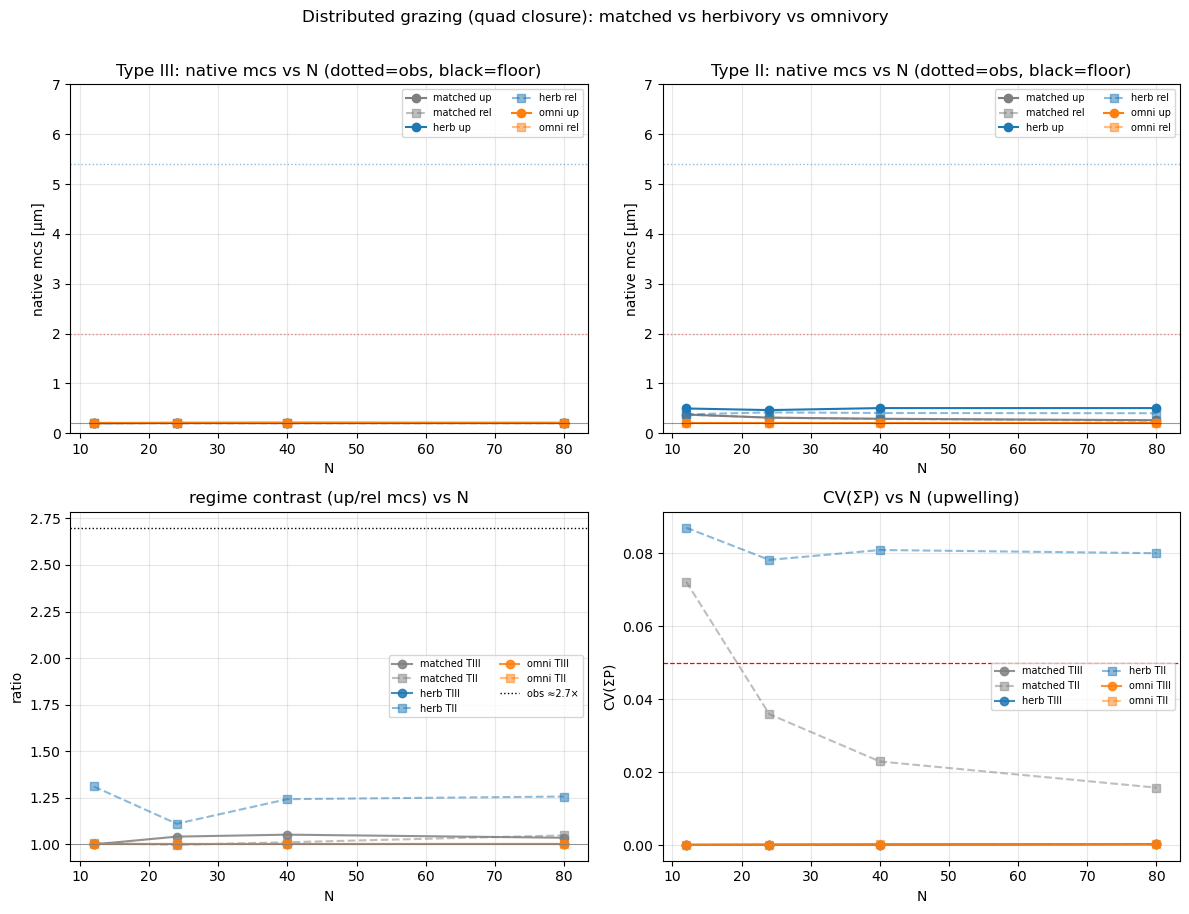

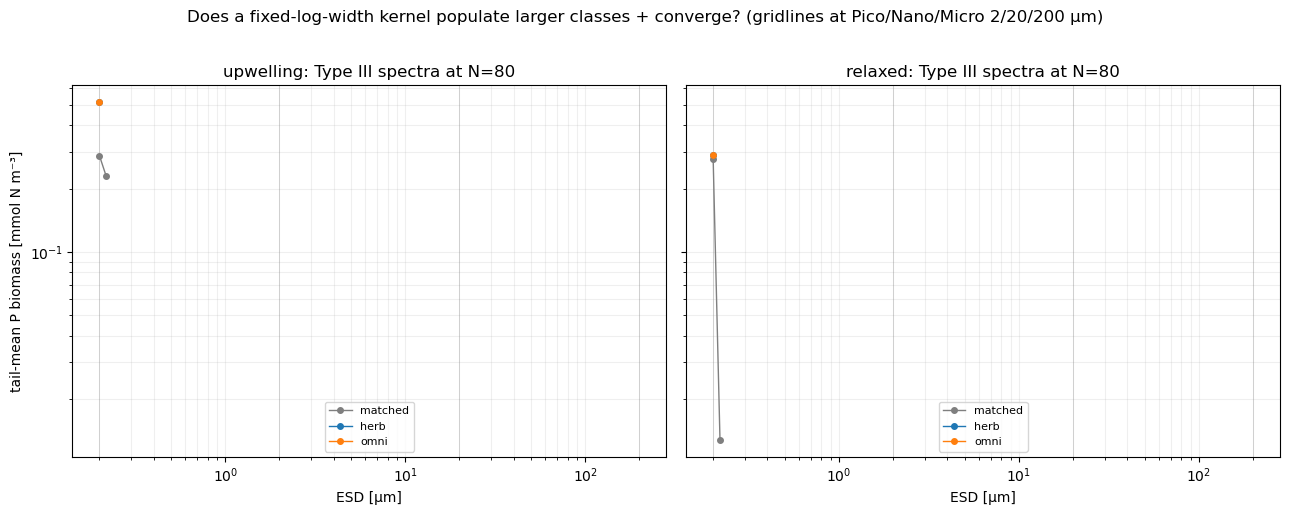

In [8]:
# ── Cell 8 — visualize distributed scan: convergence, contrast, spectra ──────
import matplotlib.pyplot as plt
MODE_COL = {'matched': 'C7', 'herb': 'C0', 'omni': 'C1'}
sd = lambda rn, N, rp, md, mt: res_dist[(rn, N, rp, md)][mt]

fig, ax = plt.subplots(2, 2, figsize=(12, 9))
for axx, rp in zip((ax[0, 0], ax[0, 1]), ('III', 'II')):
    for md in MODES:
        axx.plot(N_LIST, [sd('upwelling', N, rp, md, 'mcs_native') for N in N_LIST],
                 'o-', color=MODE_COL[md], label=f'{md} up')
        axx.plot(N_LIST, [sd('relaxed', N, rp, md, 'mcs_native') for N in N_LIST],
                 's--', color=MODE_COL[md], alpha=0.5, label=f'{md} rel')
    axx.axhline(5.4, color='C0', ls=':', lw=1, alpha=0.5)
    axx.axhline(2.0, color='C3', ls=':', lw=1, alpha=0.5)
    axx.axhline(0.2, color='k', lw=0.8, alpha=0.4)
    axx.set(title=f'Type {rp}: native mcs vs N (dotted=obs, black=floor)',
            xlabel='N', ylabel='native mcs [µm]', ylim=(0, 7))
    axx.legend(fontsize=7, ncol=2); axx.grid(alpha=0.3)

for md in MODES:
    for rp, ls in (('III', 'o-'), ('II', 's--')):
        ax[1, 0].plot(N_LIST, [sd('upwelling', N, rp, md, 'mcs_native') /
                               sd('relaxed', N, rp, md, 'mcs_native') for N in N_LIST],
                      ls, color=MODE_COL[md], alpha=0.85 if rp == 'III' else 0.5,
                      label=f'{md} T{rp}')
ax[1, 0].axhline(5.4 / 2.0, color='k', ls=':', lw=1, label='obs ≈2.7×')
ax[1, 0].axhline(1.0, color='grey', lw=0.6)
ax[1, 0].set(title='regime contrast (up/rel mcs) vs N', xlabel='N', ylabel='ratio')
ax[1, 0].legend(fontsize=7, ncol=2); ax[1, 0].grid(alpha=0.3)

for md in MODES:
    for rp, ls in (('III', 'o-'), ('II', 's--')):
        ax[1, 1].plot(N_LIST, [sd('upwelling', N, rp, md, 'cv_sumP') for N in N_LIST],
                      ls, color=MODE_COL[md], alpha=0.85 if rp == 'III' else 0.5,
                      label=f'{md} T{rp}')
ax[1, 1].axhline(0.05, color='red', ls='--', lw=0.9)
ax[1, 1].set(title='CV(ΣP) vs N (upwelling)', xlabel='N', ylabel='CV(ΣP)')
ax[1, 1].legend(fontsize=7, ncol=2); ax[1, 1].grid(alpha=0.3)
plt.suptitle('Distributed grazing (quad closure): matched vs herbivory vs omnivory',
             y=1.01); plt.tight_layout(); plt.show()

# tail-mean spectra at N=80, Type III, 3 kernels (upwelling | relaxed)
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for axx, rn in zip(ax, ('upwelling', 'relaxed')):
    for axv in (0.2, 2.0, 20.0, 200.0):
        axx.axvline(axv, color='grey', lw=0.5, alpha=0.4)
    for md in MODES:
        d = res_dist[(rn, 80, 'III', md)]
        msk = d['P_tail'] > 1e-10
        axx.loglog(d['esd'][msk], d['P_tail'][msk], 'o-', color=MODE_COL[md],
                   ms=4, lw=1, label=md)
    axx.set(title=f'{rn}: Type III spectra at N=80', xlabel='ESD [µm]')
    axx.legend(fontsize=8); axx.grid(alpha=0.2, which='both')
ax[0].set_ylabel('tail-mean P biomass [mmol N m⁻³]')
plt.suptitle('Does a fixed-log-width kernel populate larger classes + converge? '
             '(gridlines at Pico/Nano/Micro 2/20/200 µm)', y=1.02)
plt.tight_layout(); plt.show()